objective:to load dataset and do basic inspection


In [2]:
import pandas as pd
df=pd.read_csv("Iris.csv")
print("dataset loaded successfully")

dataset loaded successfully


In [3]:
df.shape

(150, 6)

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [7]:
df.duplicated().sum()

np.int64(0)

Dataset Summary

The Iris dataset has information about iris flowers like how long and wide the sepalsre how long and wide the petals are. People often use the Iris dataset to teach computers how to put things into groups. The Iris dataset has three kinds of flowers in it which helps us see how computers can use details to figure out what group something belongs to. We use the Iris dataset to learn about the Iris flowers and how to use machine learning to classify the Iris flowers based on things, like sepal length and petal width of the Iris flowers.




In [8]:
import pandas as pd
df = pd.read_csv("Iris.csv")
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [10]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [11]:
df['Species'].unique()

array([0, 1, 2])

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Species']=le.fit_transform(df['Species'])
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [13]:
x=df.drop('Species',axis=1)
y=df['Species']
print("features shape :",x.head())
print("target shape:",y.head())

features shape :    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0   1            5.1           3.5            1.4           0.2
1   2            4.9           3.0            1.4           0.2
2   3            4.7           3.2            1.3           0.2
3   4            4.6           3.1            1.5           0.2
4   5            5.0           3.6            1.4           0.2
target shape: 0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


In [14]:
x=df.drop(['Id','Species'],axis=1)
y=df['Species']
print("features shape :",x.shape)
print("target shape:",y.shape)

features shape : (150, 4)
target shape: (150,)


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
  x,y,test_size=0.2,random_state=42)
print("x_train:",x_train.shape)
print("x_test:",x_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

x_train: (120, 4)
x_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [16]:
df.corr(numeric_only=True)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,1.000000,0.716676,-0.397729,0.882747,0.899759,0.942830
SepalLengthCm,0.716676,1.000000,-0.109369,0.871754,0.817954,0.782561
SepalWidthCm,-0.397729,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
PetalLengthCm,0.882747,0.871754,-0.420516,1.000000,0.962757,0.949043
PetalWidthCm,0.899759,0.817954,-0.356544,0.962757,1.000000,0.956464
Species,0.942830,0.782561,-0.419446,0.949043,0.956464,1.000000


Data Preprocessing

I checked the dataset before model training. Found no missing values. The Species column was already in a format so I did not need to do any extra encoding.

The dataset was split into training and testing sets with 80% for training and 20%, for testing.

I used the training data to build the models and the testing data to see how well they performed.

The model performance was evaluated using the testing data.

In [17]:
from sklearn.model_selection import train_test_split
X = df.drop('Species', axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (120, 5)
Testing Data Shape: (30, 5)


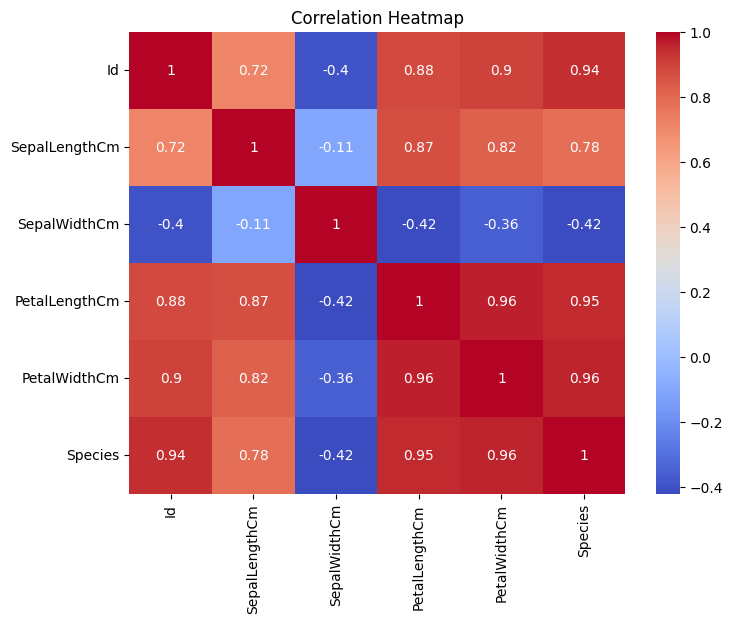

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
   cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

Observation The correlation heatmap shows how features in the dataset relate, to each other.

Petal Length and Petal Width are strongly connected.

They both go up together.

These two features, Length and Petal Width have a strong positive correlation.

The features Petal Length and Petal Width are related.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


The KNN model was. It worked really well. We used the test dataset to see how good it is. The KNN model got a high accuracy score. This means the KNN model is really good, at telling what kind of iris flower something is.



In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [22]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0
2,Random Forest,1.0


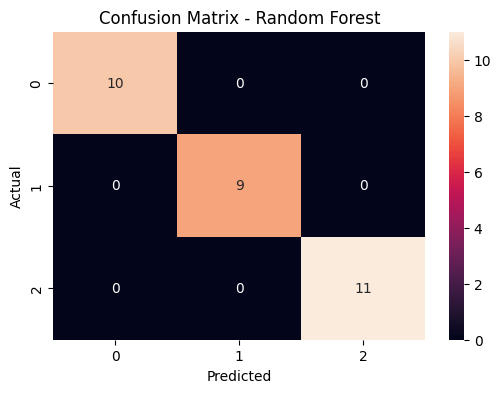

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Comparison

We looked at three machine learning models that were trained and tested using the Iris dataset.

1.Logistic Regression

2.K-Nearest Neighbors, which is also known as KNN

3.Random Forest

We then compared how accurate each of the three models were. The Iris dataset was used for all three models. All the models did a job with the Iris dataset but the Random Forest model did a really good job. The Random Forest model was very accurate. We compared the accuracy scores of the Logistic Regression model and the K-Nearest Neighbors model, to the Random Forest model. The Random Forest model was the best.

# Confusion Matrix Analysis
I took a look at the best model we have. I made a table called a confusion matrix to see how well it can tell the different iris flowers apart. The table showed that the model got most of the test samples right. There were not samples that the model got wrong. This means the model is really good, at telling the three types of iris flowers. So we can trust this model to do a job of classifying iris flowers.



# **Key Findings**
1.The Iris dataset was really clean. Had no missing values, which made it perfect for machine learning tasks.

2.I found that Petal Length and Petal Width were super important, in telling flower species apart.

3.All three machine learning models did great on the test dataset with high accuracy scores.

4.The Random Forest model performed the overall among the models I tested.

